In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load and clean data (same steps as before)
df = pd.read_csv('../data/city_day.csv')
df = df.drop(columns=['Xylene'])
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df = df.dropna(subset=['AQI'])
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

print("Data ready! Shape:", df.shape)

Data ready! Shape: (29531, 18)


In [4]:
# Features = what we give the model to learn from
# Target = what we want to predict

features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 
            'NH3', 'CO', 'SO2', 'O3', 'Benzene', 
            'Toluene', 'Month', 'Day', 'Year']

X = df[features]  # Input
y = df['AQI']     # Output (what we predict)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nWe are predicting AQI using", len(features), "features")

Features shape: (29531, 14)
Target shape: (29531,)

We are predicting AQI using 14 features


In [5]:
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 23624
Testing samples: 5907


In [6]:
# Create the model
model = RandomForestRegressor(
    n_estimators=100,  # 100 trees
    random_state=42
)

# Train it!
print("Training model... please wait")
model.fit(X_train, y_train)
print("Model trained successfully! ✅")

Training model... please wait
Model trained successfully! ✅


In [7]:
# Predict on test data
y_pred = model.predict(X_test)

# How good is our model?
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"\nThis means our model is {r2*100:.1f}% accurate!")

Mean Absolute Error: 19.83
R2 Score: 0.8860

This means our model is 88.6% accurate!


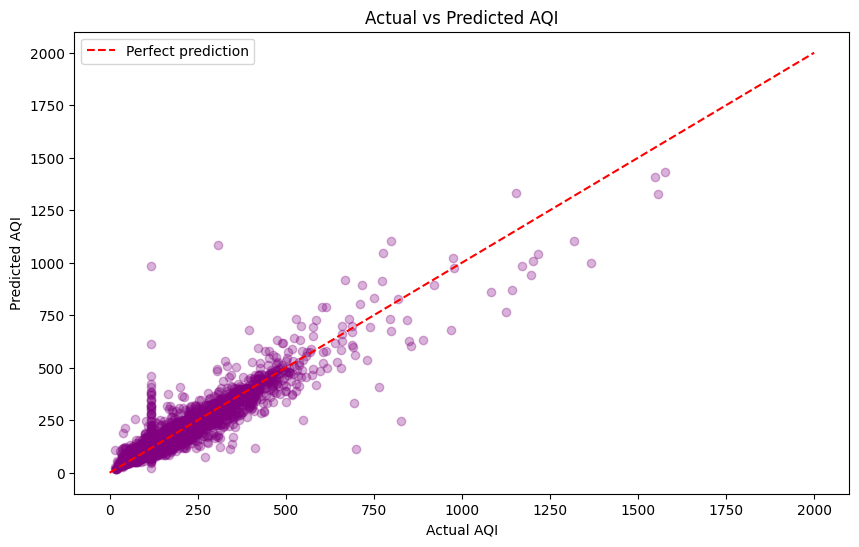

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([0, 2000], [0, 2000], 'r--', label='Perfect prediction')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.legend()
plt.show()

C:\Users\Sachin Singh\AppData\Local\Temp\ipykernel_11384\1742587688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='Reds_r')


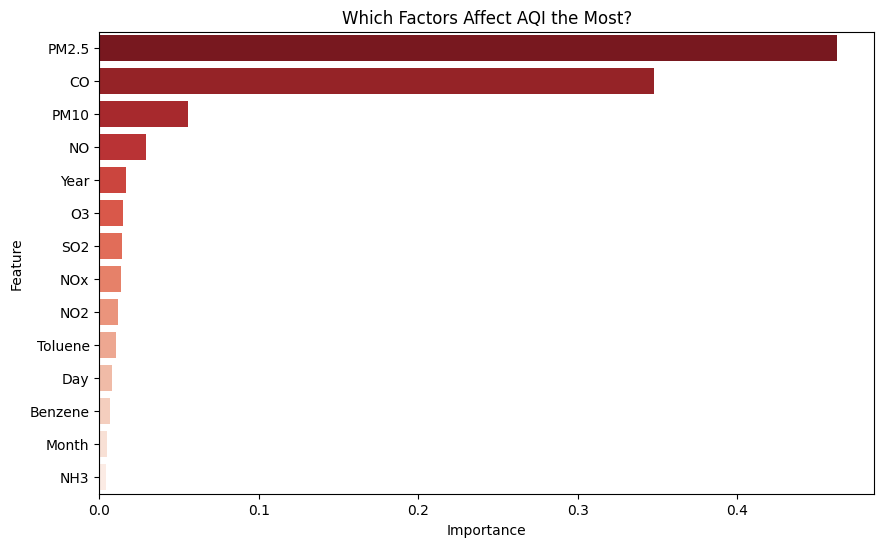

    Feature  Importance
0     PM2.5    0.462638
6        CO    0.347925
1      PM10    0.055881
2        NO    0.029481
13     Year    0.016590
8        O3    0.014858
7       SO2    0.013945
4       NOx    0.013311
3       NO2    0.011471
10  Toluene    0.010198
12      Day    0.008068
9   Benzene    0.006965
11    Month    0.004610
5       NH3    0.004060


In [9]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='Reds_r')
plt.title('Which Factors Affect AQI the Most?')
plt.show()

print(importance)